# Checkerboard data analysis

Contact: laquitainesteeve@gmail.com based on Guilhelm's guilhelm-dev branch  

Description: This notebook is the second one of the Analysis Pipeline. If you haven't run the first one (Preprocessing) until the extraction of phy's data , you don't have the files needed to run this one. In this notebook, you will use phy sorted cluster spikes of a checkerboard recording to compute clusters raster plots, ganglion cells STA and fit ellipses on their receptive fields.

Execution time: <15 min

Tested on Ubuntu 24.04.1 LTS (32 cores, 188 GB RAM, Intel(R) Core(TM) i9-14900K ＠3.2 GHz/5.8 GHz)

**Requirements:**
- Run preprocessing before

**Required by**:
- 4-Chirp+Cell Typing.ipynb notebook

## Setup

In [9]:
%reload_ext autoreload
%autoreload 2

# import packages
import os
import utils

# import custom packages
import params
from utils import analyse_checkerboard as analysis

## Load data

- All the variables used in this part of the cell should always refer to your 'params.py' file, unless you want to manually change them only for this run (i.e. debugging). You may have to add those variable into the function you want to adapt as only the minimal amount of var are currently given to functions as inputs.
- Mandatory for each run !
- Execution time: 9 secs

In [ ]:
%%time 

# === Choose the stimulus type ===
# False = checkerboard  |  True = SWN (Sparse White Noise). SWN file paths are set in params.py.
is_swn = False

# ask user to input the parameters and create the analysis directory
# (parameters are normally in the recording name; for SWN only the recording and
#  stimulus frequency are asked \u2014 the check count/size questions are skipped)
(
    recording_number,
    recording_name,
    stimulus_frequency,
    nb_checks_x,
    nb_checks_y,
    nb_pixels_per_check,
    check_directory,
) = analysis.get_all_inputs_for_checkerboard_analysis(params, is_swn=is_swn)

if is_swn:
    # SWN: reconstruct the stimulus from its .bin/.vec and also get the stimulus
    # covariance C_I used to decorrelate (whiten) the STA further down.
    checkerboard_spikes, triggers, nb_repeats, cells_id, checkerboard, C_I = (
        analysis.load_swn_data(params, recording_name, stimulus_frequency)
    )
    # one STA pixel spans 'shift' DMD pixels (the spatial down-sampling used for SWN)
    nb_pixels_per_check = params.swn_shift_x
else:
    # Checkerboard: load or regenerate the checkerboard stimulus (no decorrelation needed).
    C_I = None
    checkerboard_spikes, triggers, nb_repeats, cells_id, checkerboard = (
        analysis.load_checkerboard_data(
            params,
            check_directory,
            recording_name,
            nb_checks_x,
            nb_checks_y,
            stimulus_frequency,
        )
    )

# rep / non-rep sequence portions (checkerboard only; SWN has no repeated sequence)
repeated_sequence_portion = (0.5, 1) # portion holding the repeated sequence (second half)
non_repeated_sequence_portion = (0, 0.5) # portion holding the random sequence (first half)

## Extract responses to repeated sequence (raster plot and psth)

- Analysis on repeated sequence: all the variables used in this part of the cell should always refere to your 'params.py' file
unless you want to manually change them only for this run (i.e. debugging). 
You may have to add those variable into the function you want to adapt as only the minimal 
amount of var are currently given to functions as inputs.
- Requirements: cell 1 run
- Execution time: < 3 mins

In [ ]:
%%time

if is_swn:
    # SWN has no repeated sequence, so there are no reliability rasters to extract.
    print("SWN stimulus has no repeated sequence \u2014 skipping the reliability rasters.")
    rep_seq_data = None
else:
    # inputs
    save_data = True # save data or not
    show_all_rasters = True # show all rasters in one figure in console to check extraction
    save_single_cell_figures = False  # compute and save one figure per cell (raster+psth); can be skipped

    # extract data
    rep_seq_data = analysis.extract_all_cell_responses_to_repeated_sequences(
        checkerboard_spikes,
        triggers,
        nb_repeats,
        stimulus_frequency,
        cells_id,
        nb_frames_per_sequence=params.nb_frames_by_sequence,
        sequence_portion=repeated_sequence_portion,
    )
    if save_data:
        utils.save_obj(rep_seq_data, os.path.join(check_directory, "Check_rasters_data"))

    # plot data
    if show_all_rasters:
        analysis.plot_all_rasters(rep_seq_data, cells_id)
    if save_single_cell_figures:
        analysis.plot_and_save_single_cell_rasters(
            rep_seq_data,
            cells_id,
            check_directory,
            title="Response to repeated sequence")

## Compute STAs

- **Requirements**: requires cell 1 run
- Execution time: < 5 min

In [ ]:
%%time 

# Extract responses to non-repeated sequences, compute STA and save data
sta_data_file, sta_data = analysis.compute_spike_triggered_average(
    checkerboard_spikes,
    checkerboard,
    triggers,
    nb_repeats,
    stimulus_frequency,
    check_directory,
    temporal_dimension=params.sta_temporal_dimension,
    sequence_portion=non_repeated_sequence_portion,
    nb_frames_per_sequence=params.nb_frames_by_sequence,
    sta_data_filename="sta_data_3D.pkl",
)

Computing STAs...


 10%|█         | 24/239 [00:15<02:24,  1.49it/s]

Cell 97 has 0.0 spikes, less than 0 spikes, zero-like sta returned.


 16%|█▌        | 38/239 [00:25<02:10,  1.54it/s]

Cell 154 has 0.0 spikes, less than 0 spikes, zero-like sta returned.


...

Cell 678 has 0.0 spikes, less than 0 spikes, zero-like sta returned.


 99%|█████████▉| 237/239 [02:32<00:01,  1.49it/s]

Cell 796 has 0.0 spikes, less than 0 spikes, zero-like sta returned.


100%|██████████| 239/239 [02:32<00:00,  1.56it/s]

CPU times: user 2min 32s, sys: 99.7 ms, total: 2min 32s
Wall time: 2min 32s


Total : 239 cells found
Cell ids: [17, 19, 20, 27, 28, 31, 39, 40, 42, 44, 46, 47, 48, 50, 59]...


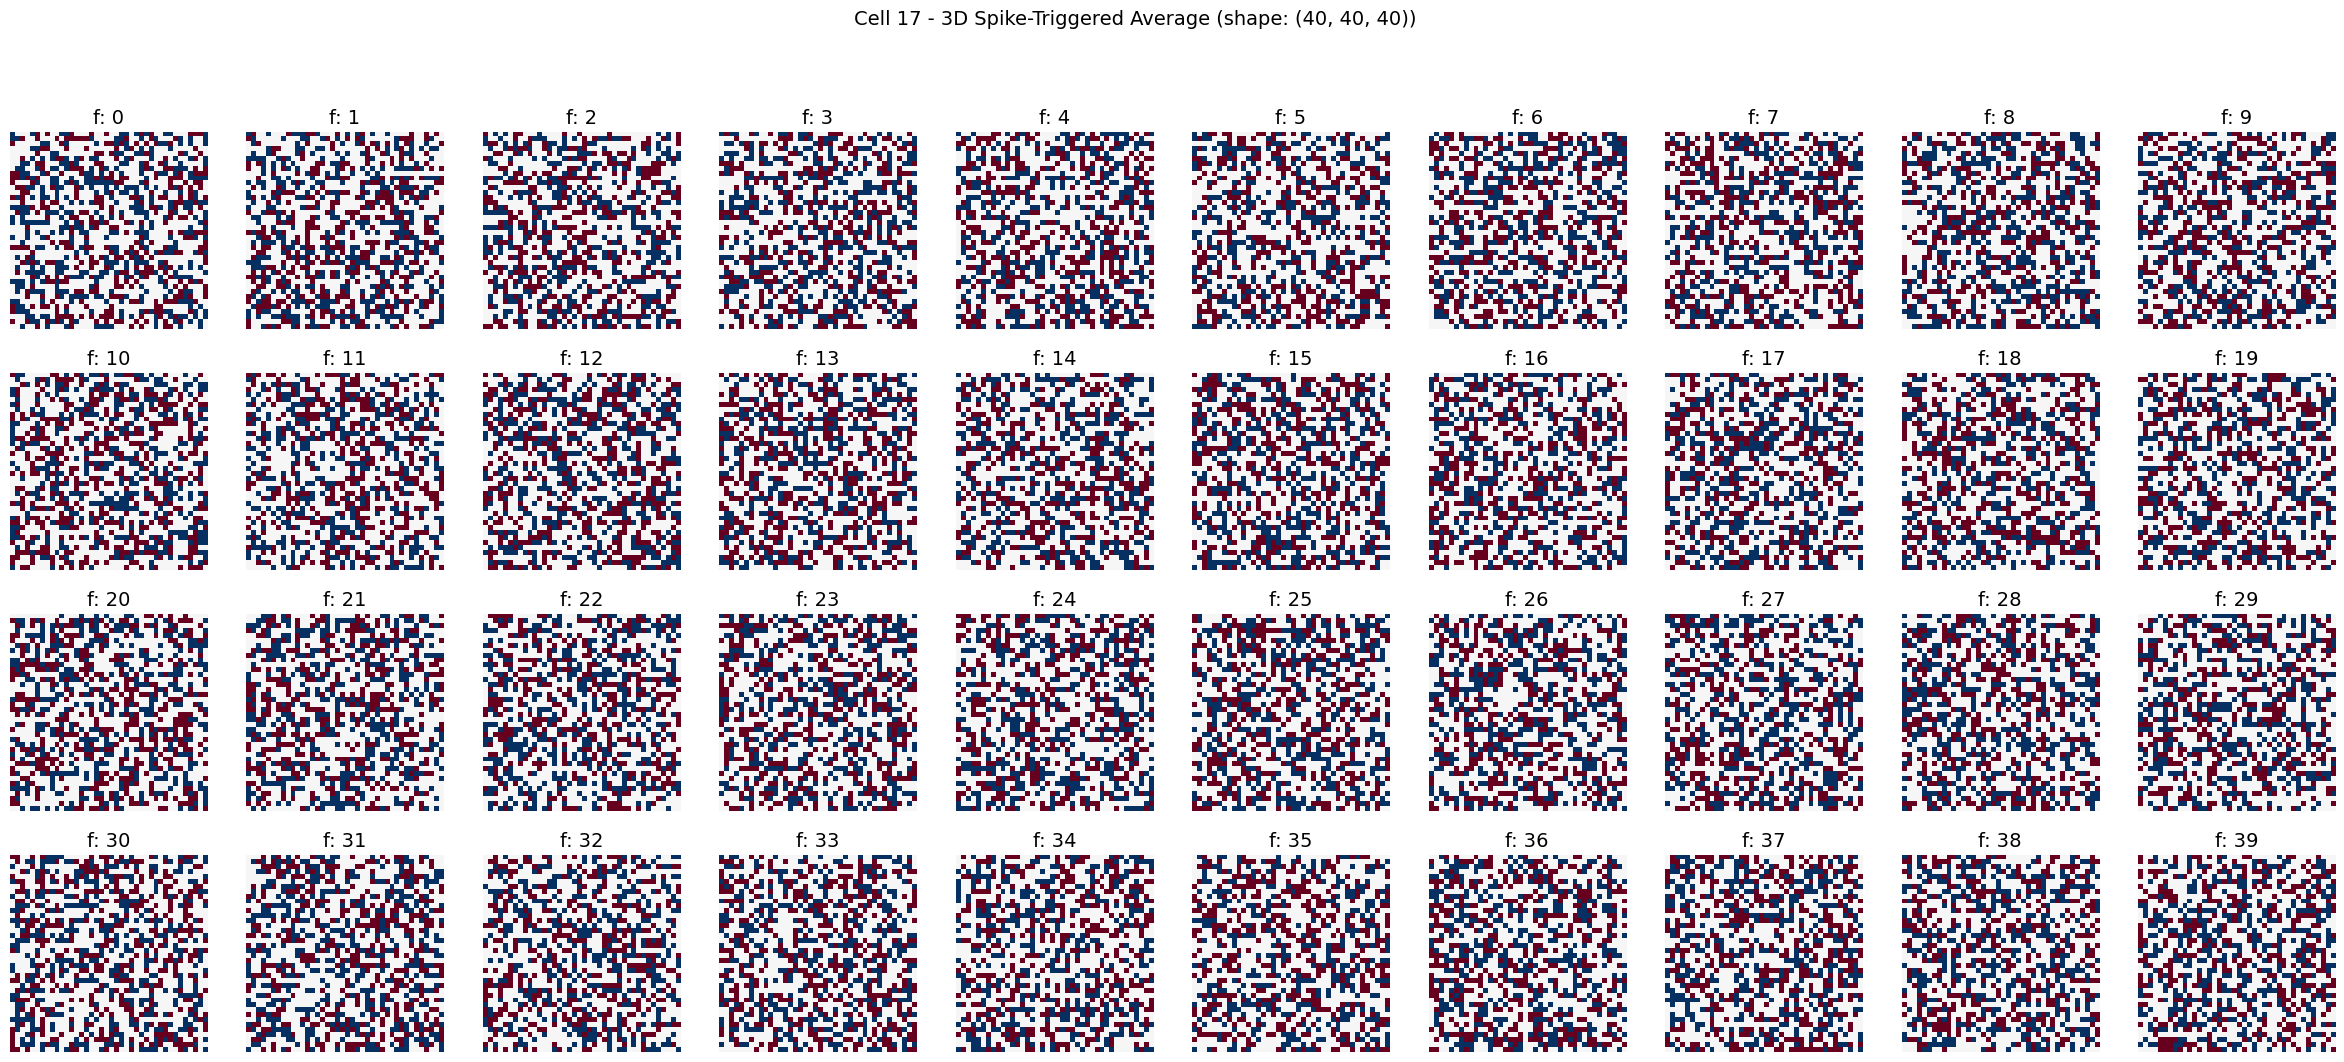

CPU times: user 615 ms, sys: 29.1 ms, total: 644 ms
Wall time: 11.3 s


In [ ]:
%%time 

# Check STA computation for one example cell
# ask the user to input a cell and plot its 3D sta (e.g., 1)
analysis.plot_one_cell_3D_spike_triggered_average(
    sta_data, 
    max_frames_to_show=params.sta_temporal_dimension,
    n_frames_per_line=10,
    fontsize=14)

## Analyse STAs to identify receptive fields

- **Requirements**: requires cell 1 run and cell 4 output
- Execution time: 10 secs

In [ ]:
%%time 

load_sta_data = True # load previously computed sta data or not (if not, it will compute it again and overwrite the previous one if it exists)
show_all_stas = True
get_extended_analysis = True

if load_sta_data:
    sta_data_file = os.path.join(check_directory, "sta_data_3D.pkl")
    sta_data = utils.load_obj(sta_data_file)

# Analyze STAs to extract receptive field properties for all cells, 
# add it to the sta_data dictionary and save it
sta_data_analysed = analysis.analyse_all_stas(
    sta_data, 
    directory=check_directory,
    data_filename="sta_data_analysed.pkl",
    method="standard"
)

# SWN only: the sparse-noise stimulus is spatially correlated, so whiten each spatial
# STA by the inverse stimulus covariance (C_I) and re-fit the ellipse. The checkerboard
# is already white and skips this. It overwrites the RF in place, so the steps below are unchanged.
if is_swn:
    sta_data_analysed = analysis.decorrelate_spatial_stas(sta_data_analysed, C_I)

# Extend analysis to physical units
# adding to the analysis dictionary the RF properties in physical units (um, s, etc.) and not only in pixels and time bins as before,
# and stores the results
if get_extended_analysis:
    sta_data_analysed = analysis.extend_sta_analysis_to_physical_units(
        sta_data_analysed,
        pixels_per_check=nb_pixels_per_check,
        pxl_size_dmd_um=params.pxl_size_dmd,
        sta_frequency=stimulus_frequency,
        directory=check_directory,
        data_filename="sta_data_analysed_extended.pkl",
    )

if show_all_stas:
    # n_sigma: RF ellipse / SNR mask taken at this many standard deviations of the fitted Gaussian
    analysis.plot_all_stas(sta_data_analysed, n_sigma=2, order_by_property="rf_snr", border_width=3)

## Visualize receptive fields 

- Check the figure saved in the Analysis/ folder.
- Execution time: 30 secs

In [ ]:
%%time

# Re-loading analysed STA data if already computed and saved, 
# to run following analysis without re-computing it
# - False if you run the previous cell to compute the analysed STA data, so it is already in memory
# - True if you just want to run following analysis and the analysed STA data has already been computed and saved (in this case only import and first cell are needed)
load_sta_data = True
if load_sta_data:
    sta_data_analysed_file = os.path.join(check_directory, "sta_data_analysed.pkl")
    sta_data_extended_file = os.path.join(check_directory, "sta_data_analysed_extended.pkl")
    if os.path.exists(sta_data_extended_file):
        sta_data_analysed = utils.load_obj(sta_data_extended_file)
        print(f"Loaded extended analysed STA data from {sta_data_extended_file}")
    elif os.path.exists(sta_data_analysed_file):
        sta_data_analysed = utils.load_obj(sta_data_analysed_file)
        print(f"Loaded analysed STA data from {sta_data_analysed_file}")
    else:
        print("Analysed STA data file not found. Check the filename or run the previous cell to compute and save the analysed STA data before running this cell.")
    # SWN has no repeated sequence -> no rasters to overlay
    rep_seq_data = None
    rep_seq_data_file = os.path.join(check_directory, "Check_rasters_data.pkl")
    if is_swn:
        print("SWN: no repeated-sequence rasters to overlay on the STAs.")
    elif os.path.exists(rep_seq_data_file):
        rep_seq_data = utils.load_obj(rep_seq_data_file)
    else:
        print(f"Repeated sequence data file not found at {rep_seq_data_file}. Check the filename or run the previous cell to compute and save the repeated sequence data before running this cell.")    

# Plotting STAs & their fitted ellipses for all cells 
analysis.plot_sta_fitted_with_ellipse(
    sta_data_analysed, 
    check_directory,
    add_raster_plot=rep_seq_data is not None,  # SWN has no rasters
    rep_seq_data=rep_seq_data,
    add_spatial_mask=True,
    cell_ids=None, # list of cell ids to plot, e.g., [208, 209, 210], if None it will plot all cells
    show_figures=False,
    n_sigma=2,  # RF ellipse / SNR mask taken at this many standard deviations of the fitted Gaussian
    xdim=8,
    ydim=5,
    save_format="png"
)